<a href="https://colab.research.google.com/github/ShantKun/Implementation-of-Unet-Segmentation-Model-on-BUSI-dataset/blob/main/Unet1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.8 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from glob import glob
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/BUSI/archive (3).zip"

extract_path = "/content/BUSI"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

os.listdir("/content/BUSI")

['Dataset_BUSI_with_GT']

In [ ]:
dataset_path = "/content/BUSI/Dataset_BUSI_with_GT"

In [ ]:
image_paths = []
mask_paths = []

classes = ["benign", "malignant", "normal"]

for cls in classes:

    cls_path = os.path.join(dataset_path, cls)

    images = glob(os.path.join(cls_path, "*.png"))

    for img_path in images:

        # Skip masks
        if "_mask" in img_path:
            continue

        mask_path = img_path.replace(".png", "_mask.png")

        # Check if mask exists
        if os.path.exists(mask_path):

            image_paths.append(img_path)
            mask_paths.append(mask_path)

In [ ]:
print("Total Images:", len(image_paths))
print("Total Masks :", len(mask_paths))

Total Images: 780
Total Masks : 780


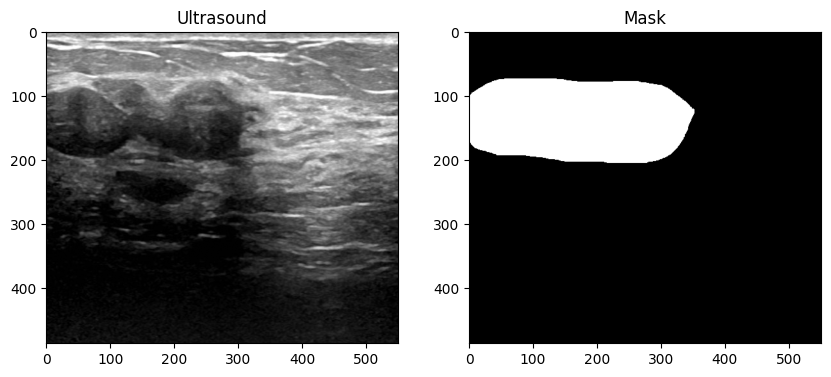

In [ ]:
idx = 10

img = cv2.imread(image_paths[idx], cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(mask_paths[idx], cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Ultrasound")

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask")

plt.show()

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    image_paths,
    mask_paths,
    test_size=0.3,
    random_state=42
)

print(len(X_train), len(X_val))

546 234


In [ ]:
!pip install albumentations
import albumentations as A
from albumentations.pytorch import ToTensorV2

#Data Augmentation Pipeline

train_transform = A.Compose([

    A.HorizontalFlip(p=0.5),

    A.VerticalFlip(p=0.3),

    A.Rotate(limit=20, p=0.5),

    # ── NEW: stronger augmentations to fight overfitting ──────────────
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.4
    ),

    A.GaussianBlur(blur_limit=(3, 5), p=0.3),

    A.ElasticTransform(p=0.3),

    A.GridDistortion(p=0.2),

    A.CoarseDropout(
        max_holes=4,
        max_height=32,
        max_width=32,
        fill_value=0,
        p=0.2
    ),
    # ─────────────────────────────────────────────────────────────────

    # FIX: max_pixel_value=1.0 because image is already in [0, 1]
    A.Normalize(
        mean=(0.485,),
        std=(0.229,),
        max_pixel_value=1.0      # ← THIS was the critical bug
    ),

    ToTensorV2()

])

val_transform = A.Compose([

    # FIX: same correction here
    A.Normalize(
        mean=(0.485,),
        std=(0.229,),
        max_pixel_value=1.0      # ← fixed
    ),

    ToTensorV2()

])

/tmp/ipykernel_2480/2254932250.py:28: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


In [ ]:
class BUSIDataset(Dataset):

    def __init__(
        self,
        images,
        masks,
        transform=None
    ):

        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = cv2.imread(
            self.images[idx],
            cv2.IMREAD_GRAYSCALE
        )

        mask = cv2.imread(
            self.masks[idx],
            cv2.IMREAD_GRAYSCALE
        )

        image = cv2.resize(
            image,
            (256,256),
            interpolation=cv2.INTER_LINEAR
        )

        mask = cv2.resize(
            mask,
            (256,256),
            interpolation=cv2.INTER_NEAREST
        )

        image = image.astype(np.float32) / 255.0

        mask = (mask > 127).astype(np.float32)

        if self.transform:

            augmented = self.transform(
                image=image,
                mask=mask
            )

            image = augmented["image"]
            mask = augmented["mask"]

            mask = mask.unsqueeze(0)

        else:

            image = torch.tensor(
                image
            ).unsqueeze(0)

            mask = torch.tensor(
                mask
            ).unsqueeze(0)

        return image, mask

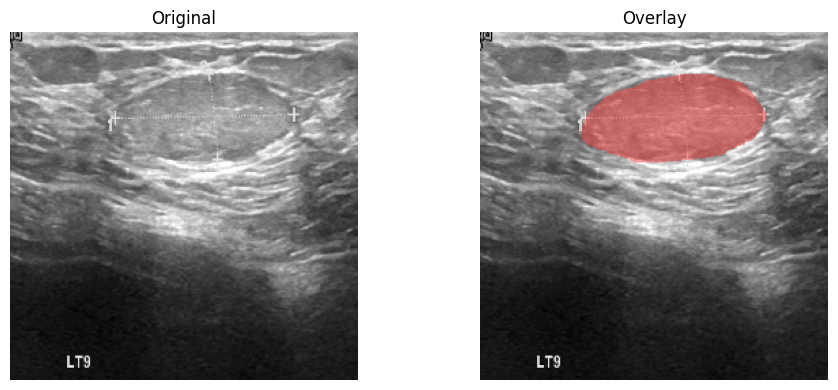

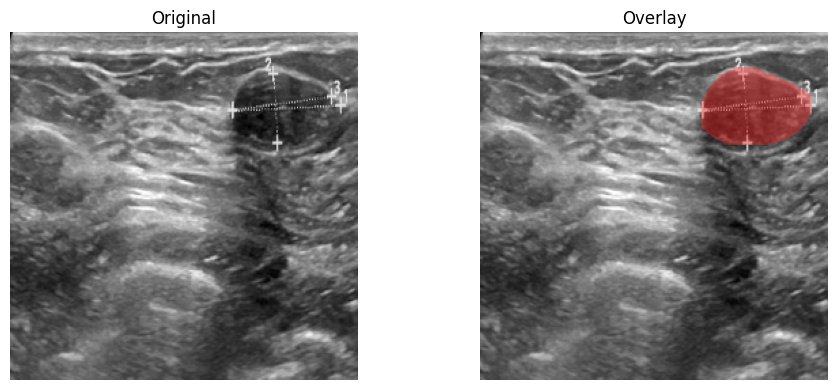

In [ ]:
def show_overlay(img_path, mask_path, color=(255, 50, 50), alpha=0.45):
    img  = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask_local = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) # Load mask locally

    img = cv2.resize(img, (256, 256), interpolation=cv2.INTER_LINEAR)
    mask_local = cv2.resize(mask_local, (256, 256), interpolation=cv2.INTER_NEAREST)

    rgb  = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    overlay = rgb.copy()
    overlay[mask_local > 127] = color
    blended = cv2.addWeighted(rgb, 1-alpha, overlay, alpha, 0)

    _, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, im, title in zip(axes,
                              [img, blended],
                              ["Original", "Overlay"]):
        ax.imshow(im, cmap='gray' if im.ndim == 2 else None)
        ax.set_title(title, fontsize=12)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Show samples from each class
for idx in [20,30]:
    show_overlay(image_paths[idx], mask_paths[idx])

In [ ]:
train_dataset = BUSIDataset(
    X_train,
    y_train,
    transform=train_transform
)

val_dataset = BUSIDataset(
    X_val,
    y_val,
    transform=val_transform
)

In [ ]:


train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

In [ ]:
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)

torch.Size([8, 1, 256, 256])
torch.Size([8, 1, 256, 256])


In [ ]:
class DoubleConv(nn.Module):

    def __init__(self, in_c, out_c):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.down1 = DoubleConv(1, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        # FIX: wrap bridge in Sequential to add Dropout2d
        self.bridge = nn.Sequential(
            DoubleConv(256, 512),
            nn.Dropout2d(p=0.3)          # ← NEW
        )

        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv1 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv3 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):

        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        b = self.bridge(p3)          # Dropout is applied automatically here

        u1 = self.up1(b)
        u1 = torch.cat([u1, d3], dim=1)
        u1 = self.conv1(u1)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u3 = self.up3(u2)
        u3 = torch.cat([u3, d1], dim=1)
        u3 = self.conv3(u3)

        return self.final(u3)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


print(device)
model = UNet().to(device)

cuda


In [ ]:
from torchsummary import summary
summary(model, input_size=(1, 256, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 256, 256]             640
       BatchNorm2d-2         [-1, 64, 256, 256]             128
              ReLU-3         [-1, 64, 256, 256]               0
            Conv2d-4         [-1, 64, 256, 256]          36,928
       BatchNorm2d-5         [-1, 64, 256, 256]             128
              ReLU-6         [-1, 64, 256, 256]               0
        DoubleConv-7         [-1, 64, 256, 256]               0
         MaxPool2d-8         [-1, 64, 128, 128]               0
            Conv2d-9        [-1, 128, 128, 128]          73,856
      BatchNorm2d-10        [-1, 128, 128, 128]             256
             ReLU-11        [-1, 128, 128, 128]               0
           Conv2d-12        [-1, 128, 128, 128]         147,584
      BatchNorm2d-13        [-1, 128, 128, 128]             256
             ReLU-14        [-1, 128, 1

In [ ]:
import torch

def dice_score(pred, target, smooth=1e-6):

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()

    dice = (
        2.0 * intersection + smooth
    ) / (
        pred.sum() + target.sum() + smooth
    )

    return dice


def iou_score(pred, target, smooth=1e-6):

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()

    union = (
        pred.sum() +
        target.sum() -
        intersection
    )

    iou = (
        intersection + smooth
    ) / (
        union + smooth
    )

    return iou

In [ ]:
import torch

def dice_score(pred, target, smooth=1e-6):

    pred = pred.view(-1)

    target = target.view(-1)

    intersection = (
        pred * target
    ).sum()

    dice = (
        2.0 * intersection + smooth
    ) / (
        pred.sum() +
        target.sum() +
        smooth
    )

    return dice


def iou_score(pred, target, smooth=1e-6):

    pred = pred.view(-1)

    target = target.view(-1)

    intersection = (
        pred * target
    ).sum()

    union = (
        pred.sum() +
        target.sum() -
        intersection
    )

    return (
        intersection + smooth
    ) / (
        union + smooth
    )


def precision_score(pred, target, smooth=1e-6):

    pred = pred.view(-1)

    target = target.view(-1)

    tp = (
        pred * target
    ).sum()

    fp = (
        pred * (1 - target)
    ).sum()

    return (
        tp + smooth
    ) / (
        tp + fp + smooth
    )


def recall_score(pred, target, smooth=1e-6):

    pred = pred.view(-1)

    target = target.view(-1)

    tp = (
        pred * target
    ).sum()

    fn = (
        (1 - pred) * target
    ).sum()

    return (
        tp + smooth
    ) / (
        tp + fn + smooth
    )

In [ ]:
def validate(model, loader):

    model.eval()

    epoch_loss = 0

    total_dsc = 0
    total_iou = 0

    total_precision = 0
    total_recall = 0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)

            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                masks
            )

            epoch_loss += loss.item()

            probs = torch.sigmoid(
                outputs
            )

            preds = (
                probs > 0.5
            ).float()

            dsc = dice_score(
                preds,
                masks
            )

            iou = iou_score(
                preds,
                masks
            )

            precision = precision_score(
                preds,
                masks
            )

            recall = recall_score(
                preds,
                masks
            )

            total_dsc += dsc.item()

            total_iou += iou.item()

            total_precision += precision.item()

            total_recall += recall.item()

    avg_loss = epoch_loss / len(loader)

    avg_dsc = total_dsc / len(loader)

    avg_iou = total_iou / len(loader)

    avg_precision = (
        total_precision / len(loader)
    )

    avg_recall = (
        total_recall / len(loader)
    )

    return (
        avg_loss,
        avg_dsc,
        avg_iou,
        avg_precision,
        avg_recall
    )

In [ ]:
import torch
import torch.nn as nn
model = UNet().to(device)
# =========================
# METRIC STORAGE
# =========================

train_losses = []
val_losses = []

val_dsc_scores = []
val_iou_scores = []

val_precision_scores = []
val_recall_scores = []


# =========================
# BCE + DICE LOSS
# =========================

class BCEDiceLoss(nn.Module):

    def __init__(self, pos_weight=3.0):

        super().__init__()

        # FIX: pos_weight penalises false positives more aggressively
        self.bce = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([pos_weight]).to(device)  # ← NEW
        )

    def forward(self, outputs, targets):

        # BCE part
        bce = self.bce(outputs, targets)

        # Probabilities
        probs = torch.sigmoid(outputs)

        # FIX: compute dice PER SAMPLE, then average over the batch
        # dims=(1,2,3) sums over C, H, W for each image independently
        dims = (1, 2, 3)                                       # ← NEW

        intersection = (probs * targets).sum(dim=dims)         # ← NEW

        dice = (
            2.0 * intersection + 1e-6
        ) / (
            probs.sum(dim=dims) + targets.sum(dim=dims) + 1e-6
        )                                                      # ← NEW

        dice_loss = (1 - dice).mean()                          # ← NEW (was a scalar before)

        return 0.3 * bce + 0.7 * dice_loss

criterion = BCEDiceLoss()

# =========================
# TRAIN FUNCTION
# =========================

def train_one_epoch(
    model,
    loader,
    optimizer
):

    model.train()

    epoch_loss = 0

    for images, masks in loader:

        images = images.to(device)

        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            masks
        )

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)


# =========================
# OPTIMIZER
# =========================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=15,
    factor=0.5
)

# =========================
# TRAINING CONFIG
# =========================

num_epochs = 110

best_dsc = 0

patience = 15

trigger_times = 0


# =========================
# TRAINING LOOP
# =========================

for epoch in range(num_epochs):

    # TRAINING
    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer
    )

    # VALIDATION
    (
        val_loss,
        val_dsc,
        val_iou,
        val_precision,
        val_recall
    ) = validate(
        model,
        val_loader
    )

    # STORE METRICS
    train_losses.append(train_loss)

    val_losses.append(val_loss)

    val_dsc_scores.append(val_dsc)

    val_iou_scores.append(val_iou)

    val_precision_scores.append(
        val_precision
    )

    val_recall_scores.append(
        val_recall
    )

    # PRINT RESULTS
    print(f"Epoch [{epoch+1}/{num_epochs}]")

    print(f"Train Loss : {train_loss:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")

    print(f"DSC Score  : {val_dsc:.4f}")

    print(f"IoU Score  : {val_iou:.4f}")

    print(f"Precision  : {val_precision:.4f}")

    print(f"Recall     : {val_recall:.4f}")

    print("-"*50)


    # =========================
    # SAVE BEST MODEL
    # =========================

    if val_dsc > best_dsc:
      best_dsc = val_dsc
      trigger_times = 0
      torch.save(model.state_dict(), 'best_model.pth')   # save best checkpoint
    else:
        trigger_times += 1


    # =========================
    # EARLY STOPPING
    # =========================
    scheduler.step(val_dsc)

    if trigger_times >= patience:

        print("Early stopping triggered!")

        break

Epoch [1/110]
Train Loss : 0.8066
Val Loss   : 0.7669
DSC Score  : 0.3240
IoU Score  : 0.1973
Precision  : 0.2304
Recall     : 0.6395
--------------------------------------------------
Epoch [2/110]
Train Loss : 0.7321
Val Loss   : 0.7701
DSC Score  : 0.3155
IoU Score  : 0.1927
Precision  : 0.2052
Recall     : 0.7995
--------------------------------------------------
Epoch [3/110]
Train Loss : 0.7060
Val Loss   : 0.7403
DSC Score  : 0.3359
IoU Score  : 0.2064
Precision  : 0.2319
Recall     : 0.7149
--------------------------------------------------
Epoch [4/110]
Train Loss : 0.6832
Val Loss   : 0.6556
DSC Score  : 0.4820
IoU Score  : 0.3247
Precision  : 0.4308
Recall     : 0.5981
--------------------------------------------------
Epoch [5/110]
Train Loss : 0.6703
Val Loss   : 0.6390
DSC Score  : 0.5336
IoU Score  : 0.3703
Precision  : 0.5026
Recall     : 0.6120
--------------------------------------------------
Epoch [6/110]
Train Loss : 0.6494
Val Loss   : 0.6429
DSC Score  : 0.4699
I

In [ ]:
import seaborn as sns
from sklearn.metrics import r2_score, confusion_matrix

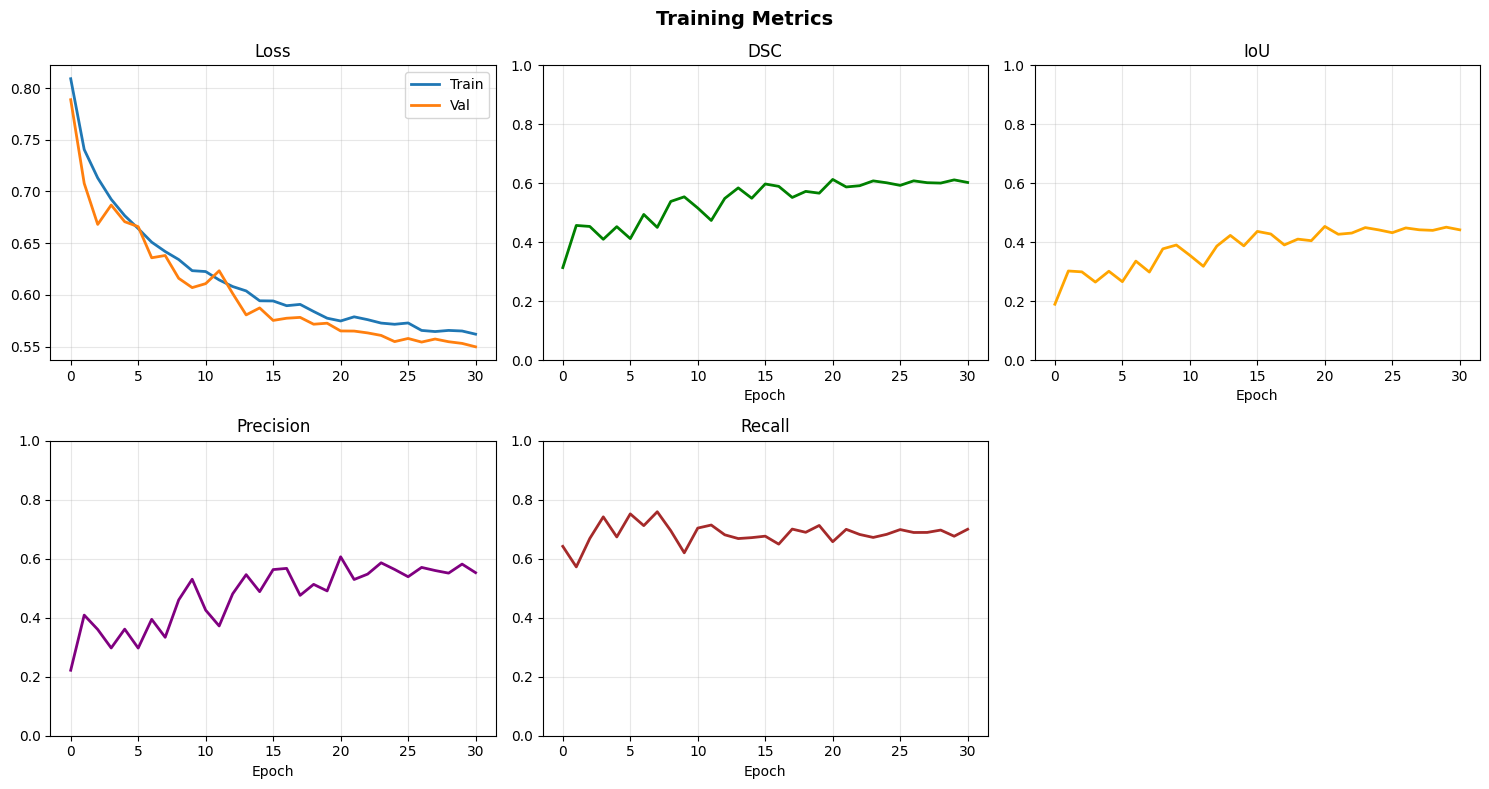

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Loss: train vs val on same plot
axes[0,0].plot(train_losses, label='Train', linewidth=2)
axes[0,0].plot(val_losses,   label='Val',   linewidth=2)
axes[0,0].set_title("Loss"); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# Individual metric curves
for ax, data, title, color in zip(
    [axes[0,1], axes[0,2], axes[1,0], axes[1,1]],
    [val_dsc_scores, val_iou_scores, val_precision_scores, val_recall_scores],
    ["DSC", "IoU", "Precision", "Recall"],
    ["green", "orange", "purple", "brown"]
):
    ax.plot(data, color=color, linewidth=2)
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.grid(alpha=0.3)
    ax.set_ylim(0, 1)

axes[1,2].set_visible(False)          # hide the unused 6th panel
plt.suptitle("Training Metrics", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

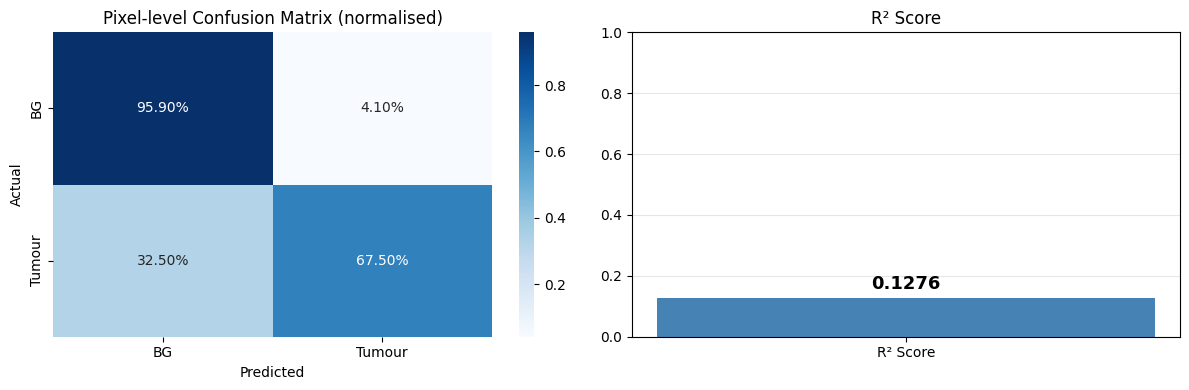

In [ ]:
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for imgs, masks in val_loader:
        preds = (torch.sigmoid(model(imgs.to(device))) > 0.5).float().cpu()
        all_preds.append(preds.view(-1).numpy())
        all_targets.append(masks.view(-1).numpy())

all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# Normalised confusion matrix (percentages)
cm     = confusion_matrix(all_targets, all_preds, normalize='true')
r2     = r2_score(all_targets, all_preds)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', ax=ax1,
            xticklabels=['BG', 'Tumour'],
            yticklabels=['BG', 'Tumour'])
ax1.set_xlabel("Predicted"); ax1.set_ylabel("Actual")
ax1.set_title("Pixel-level Confusion Matrix (normalised)")

ax2.bar(['R² Score'], [r2], color='steelblue', width=0.35)
ax2.set_ylim(0, 1); ax2.set_title(f"R² Score")
ax2.text(0, r2 + 0.03, f'{r2:.4f}', ha='center', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
model.eval()

images, masks = next(iter(val_loader))

images = images.to(device)

with torch.no_grad():

    outputs = model(images)

preds = (torch.sigmoid(outputs) > 0.5).float()

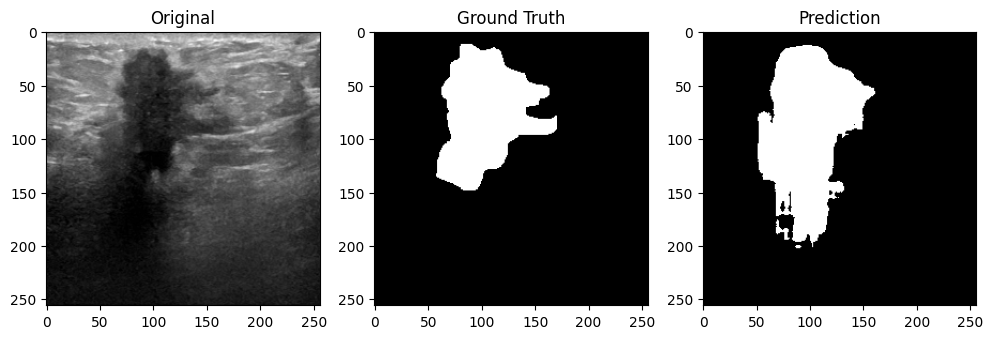

In [ ]:
idx = 0

image = images[idx].cpu().squeeze()
mask = masks[idx].squeeze()
pred = preds[idx].cpu().squeeze()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred, cmap='gray')
plt.title("Prediction")

plt.show()